In [3]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Ground Data EDA

In [4]:
measurement_folder = Path('Data/irradiation_measurements')
cbe_measurements = measurement_folder / 'CBE_Data'
mak_measurements = measurement_folder / 'MAK_physics_dept'
ministry_measurements = measurement_folder / 'ministry_energy_ug'

In [5]:
location = 'soroti'
soroti = pd.read_csv(ministry_measurements / f'{location}.csv')
soroti.head()

,datetime,ghi,location
0,2020-02-01,2550.0,soroti
1,2020-02-02,6100.0,soroti
2,2020-02-03,4690.0,soroti
3,2020-02-04,6690.0,soroti
4,2020-02-05,6030.0,soroti


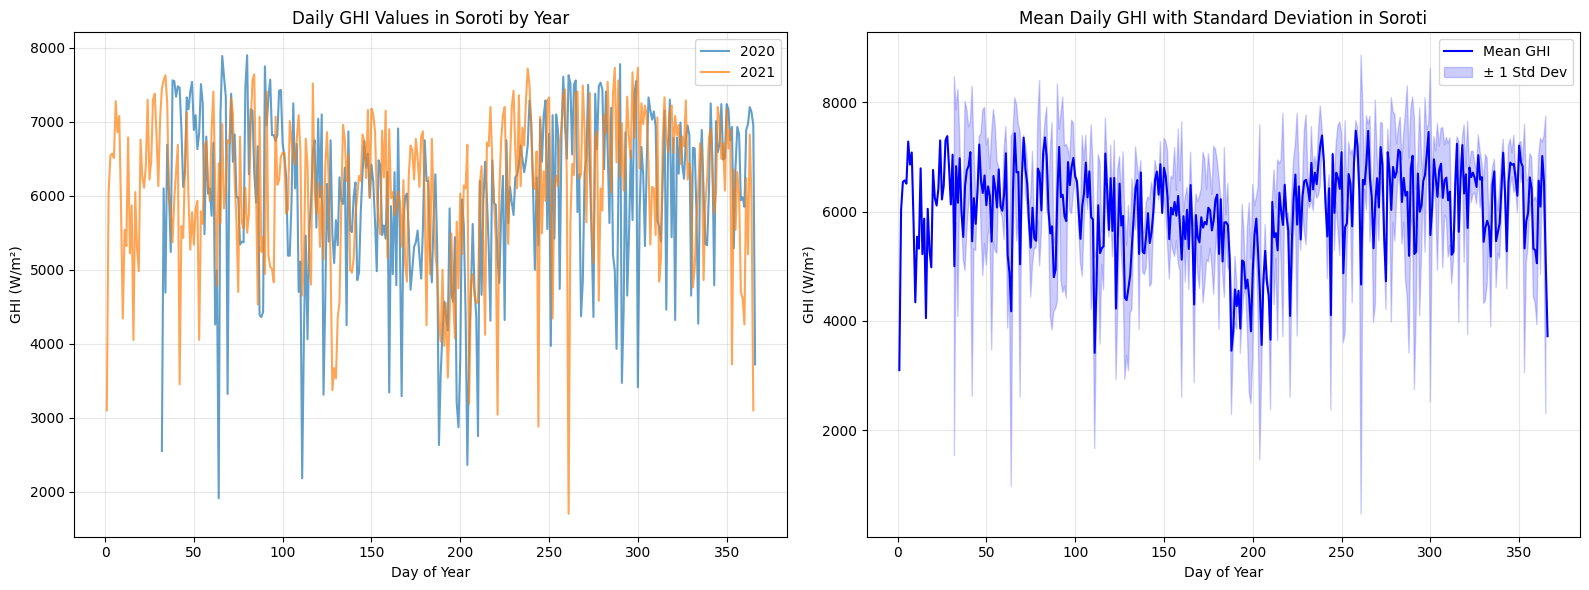

In [19]:
def plot_ghi_yearly_distribution(data, location):
    """
    Create a two-panel plot showing GHI distribution by year and daily statistics.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        DataFrame containing 'datetime' and 'ghi' columns
    location : str
        Name of the location for plot titles
        
    Returns:
    --------
    fig, axes : tuple
        Figure and axes objects for further customization if needed
    """
    # Prepare date-related columns
    data = data.copy()
    data['Date'] = pd.to_datetime(data['datetime'])
    data['Year'] = data['Date'].dt.year
    data['DayOfYear'] = data['Date'].dt.dayofyear

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left plot: GHI for all years overlayed
    years = data['Year'].unique()

    color_list = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                  '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    
    colors = [color_list[i % len(color_list)] for i in range(len(years))]

    for i, year in enumerate(years):
        year_data = data[data['Year'] == year]
        axes[0].plot(year_data['DayOfYear'], year_data['ghi'], 
                    color=colors[i],alpha=0.7, label=str(year))

    axes[0].set_xlabel('Day of Year')
    axes[0].set_ylabel('GHI (W/m²)')
    axes[0].set_title(f'Daily GHI Values in {location.capitalize()} by Year')
    axes[0].legend(loc='best')
    axes[0].grid(True, alpha=0.3)

    # Right plot: Daily mean and std across years
    daily_stats = data.groupby('DayOfYear')['ghi'].agg(['mean', 'std']).reset_index()

    axes[1].plot(daily_stats['DayOfYear'], daily_stats['mean'], 
                color='blue', label='Mean GHI')
    axes[1].fill_between(
        daily_stats['DayOfYear'], 
        daily_stats['mean'] - daily_stats['std'], 
        daily_stats['mean'] + daily_stats['std'], 
        color='blue', alpha=0.2, label='± 1 Std Dev'
    )

    axes[1].set_xlabel('Day of Year')
    axes[1].set_ylabel('GHI (W/m²)')
    axes[1].set_title(f'Mean Daily GHI with Standard Deviation in {location.capitalize()}')
    axes[1].legend(loc='best')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    
    return fig, axes

fig, axes = plot_ghi_yearly_distribution(soroti, "soroti")
plt.show()

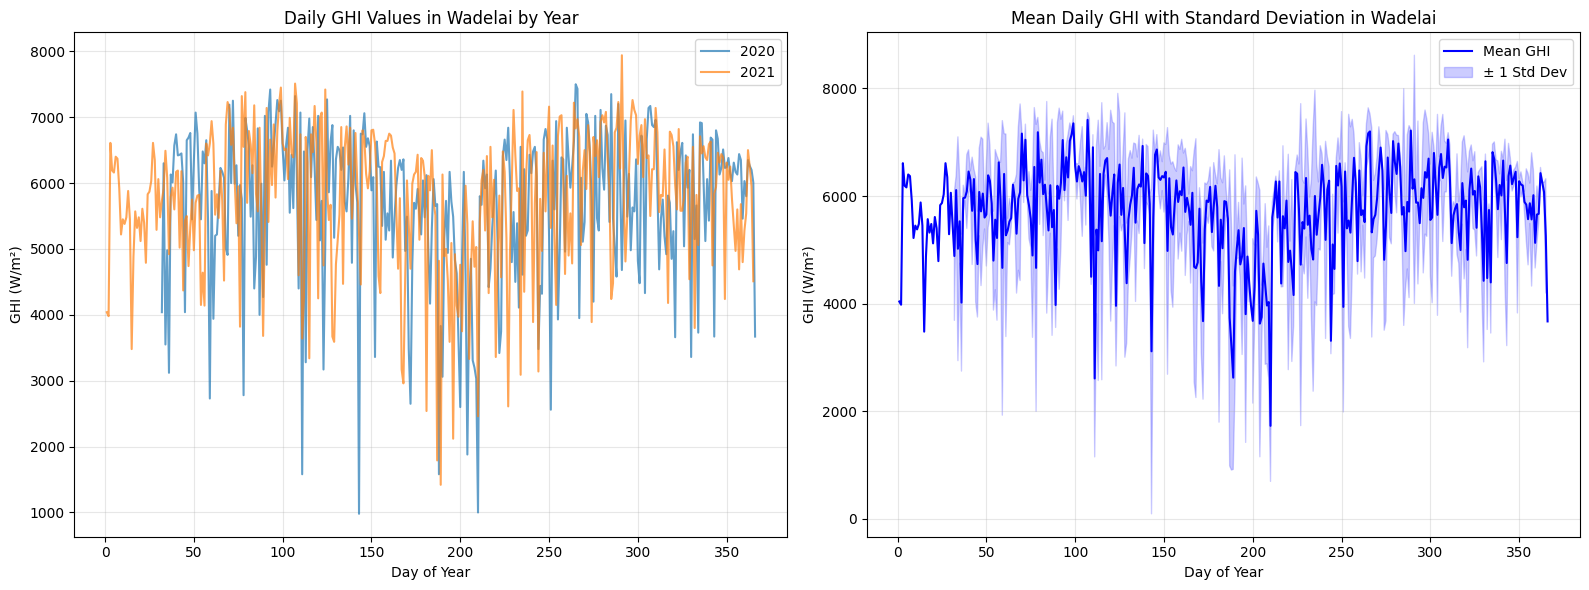

In [20]:
wadelai = pd.read_csv(ministry_measurements / 'wadelai.csv')
fig, axes = plot_ghi_yearly_distribution(wadelai, "wadelai")
plt.show()